# 🍇 Blueberry Yield Prediction with Machine Learning

<img src="https://media.post.rvohealth.io/wp-content/uploads/sites/3/2025/01/close-up-blueberries-732x549-thumbnail.jpg">

## 📌 Project Objective
The objective of this project is to predict **blueberry yield** using environmental and agronomic features.  
This is a supervised learning problem with a continuous target variable, approached as a regression task.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

## 📊 Exploratory Data Analysis 
In this section, the overall structure of the dataset is explored.  
The distribution of the target variable, presence of outliers, relationships between features and the target, and correlations among numerical variables are analyzed using visualizations.  
EDA helps in understanding data behavior and guides model selection.

In [36]:
train_df = pd.read_csv("/kaggle/input/playground-series-s3e14/train.csv")
test_df  = pd.read_csv("/kaggle/input/playground-series-s3e14/test.csv")
sample_df = pd.read_csv("/kaggle/input/playground-series-s3e14/sample_submission.csv")

In [37]:
train_df.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds,yield
0,0,25.0,0.50,0.25,0.75,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.425011,0.417545,32.460887,4476.81146
1,1,25.0,0.50,0.25,0.50,0.50,69.7,42.1,58.2,50.2,24.3,41.2,24.0,0.39,0.444908,0.422051,33.858317,5548.12201
2,2,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.552927,0.470853,38.341781,6869.77760
3,3,12.5,0.25,0.25,0.63,0.50,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.565976,0.478137,39.467561,6880.77590
4,4,25.0,0.50,0.25,0.63,0.63,77.4,46.8,64.7,55.8,27.0,45.8,24.0,0.39,0.579677,0.494165,40.484512,7479.93417


In [38]:
test_df.head()

,id,clonesize,honeybee,bumbles,andrena,osmia,MaxOfUpperTRange,MinOfUpperTRange,AverageOfUpperTRange,MaxOfLowerTRange,MinOfLowerTRange,AverageOfLowerTRange,RainingDays,AverageRainingDays,fruitset,fruitmass,seeds
0,15289,25.0,0.25,0.25,0.25,0.25,86.0,52.0,71.9,62.0,30.0,50.8,24.0,0.39,0.399367,0.408088,31.394569
1,15290,12.5,0.25,0.25,0.75,0.63,94.6,57.2,79.0,68.2,33.0,55.9,1.0,0.10,0.488048,0.442866,36.846956
2,15291,12.5,0.25,0.25,0.63,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.583379,0.487057,40.037644
3,15292,25.0,0.50,0.38,0.38,0.63,86.0,52.0,71.9,62.0,30.0,50.8,16.0,0.26,0.433014,0.422847,33.116091
4,15293,37.5,0.75,0.25,0.25,0.25,94.6,57.2,79.0,68.2,33.0,55.9,24.0,0.39,0.360996,0.388860,29.558019


In [39]:
sample_df.head()

,id,yield
0,15289,6025.194
1,15290,6025.194
2,15291,6025.194
3,15292,6025.194
4,15293,6025.194


In [40]:
train_df.shape

(15289, 18)

In [41]:
test_df.shape

(10194, 17)

In [42]:
sample_df.shape

(10194, 2)

## 🧹 Data Processing & Preparation
Before modeling, the data is processed using the following steps:
- Removal of identifier columns  
- Separation of the target variable  
- Missing value imputation for numerical features using median strategy  
- Missing value imputation and one-hot encoding for categorical features  

All preprocessing steps are applied using a unified pipeline.

In [43]:
id_col = sample_df.columns[0]
target_col = sample_df.columns[1]

In [44]:
train_df.isna().sum().sort_values(ascending=False).head()

id           0
clonesize    0
honeybee     0
bumbles      0
andrena      0
dtype: int64

In [45]:
train_df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
id,15289.0,7644.000000,4413.698468,0.000000,3822.000000,7644.000000,11466.000000,15288.000000
clonesize,15289.0,19.704690,6.595211,10.000000,12.500000,25.000000,25.000000,40.000000
honeybee,15289.0,0.389314,0.361643,0.000000,0.250000,0.500000,0.500000,18.430000
bumbles,15289.0,0.286768,0.059917,0.000000,0.250000,0.250000,0.380000,0.585000
andrena,15289.0,0.492675,0.148115,0.000000,0.380000,0.500000,0.630000,0.750000
osmia,15289.0,0.592355,0.139489,0.000000,0.500000,0.630000,0.750000,0.750000
MaxOfUpperTRange,15289.0,82.169887,9.146703,69.700000,77.400000,86.000000,86.000000,94.600000
MinOfUpperTRange,15289.0,49.673281,5.546405,39.000000,46.800000,52.000000,52.000000,57.200000
AverageOfUpperTRange,15289.0,68.656256,7.641807,58.200000,64.700000,71.900000,71.900000,79.000000
MaxOfLowerTRange,15289.0,59.229538,6.610640,50.200000,55.800000,62.000000,62.000000,68.200000


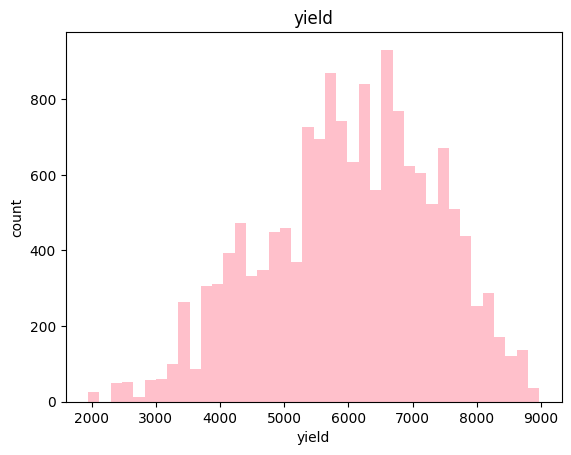

In [46]:
plt.figure()
train_df[target_col].plot(kind="hist", bins=40, color="pink")
plt.title(target_col)
plt.xlabel(target_col)
plt.ylabel("count")
plt.show()

<Figure size 640x480 with 0 Axes>

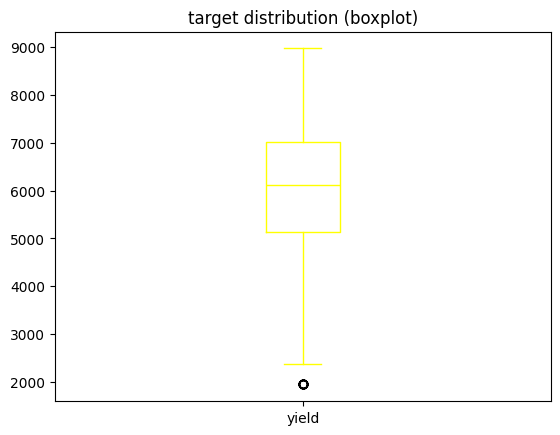

In [47]:
plt.figure()
train_df[[target_col]].plot(kind="box", color="yellow")
plt.title("target distribution (boxplot)")
plt.show()

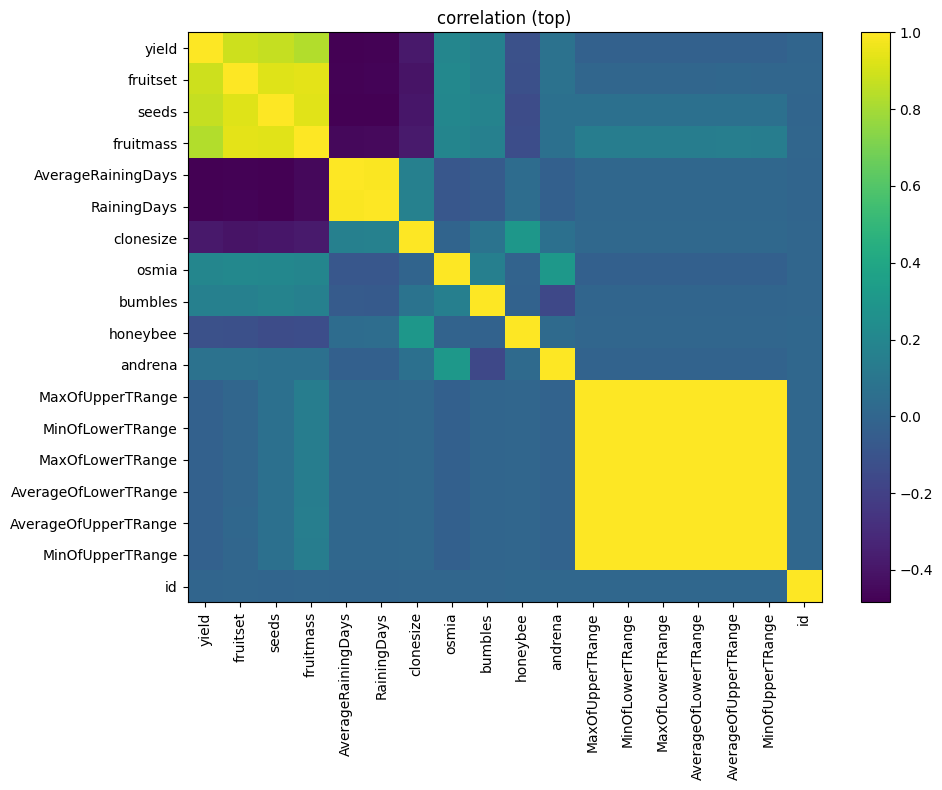

In [48]:
num_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[num_cols].corr(numeric_only=True)

top = corr[target_col].abs().sort_values(ascending=False).head(21).index
corr_top = train_df[top].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
plt.imshow(corr_top, aspect="auto")
plt.xticks(range(len(top)), top, rotation=90)
plt.yticks(range(len(top)), top)
plt.colorbar()
plt.title("correlation (top)")
plt.tight_layout()
plt.show()

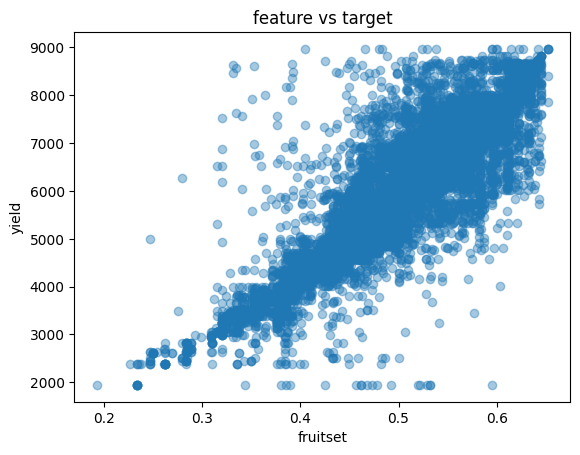

In [49]:
top_feat = corr[target_col].abs().sort_values(ascending=False).index[1]

plt.figure()
plt.scatter(train_df[top_feat], train_df[target_col], alpha=0.4)
plt.xlabel(top_feat)
plt.ylabel(target_col)
plt.title("feature vs target")
plt.show()

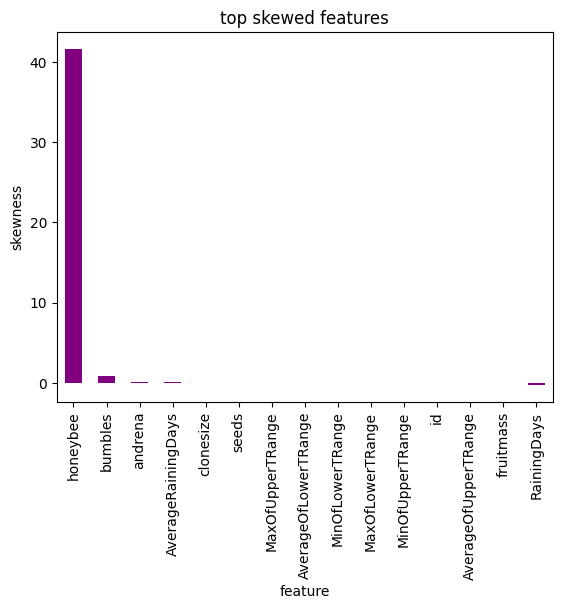

In [50]:
plt.figure()
train_df[num_cols].skew().sort_values(ascending=False).head(15).plot(kind="bar", color="purple")
plt.title("top skewed features")
plt.xlabel("feature")
plt.ylabel("skewness")
plt.xticks(rotation=90)
plt.show()

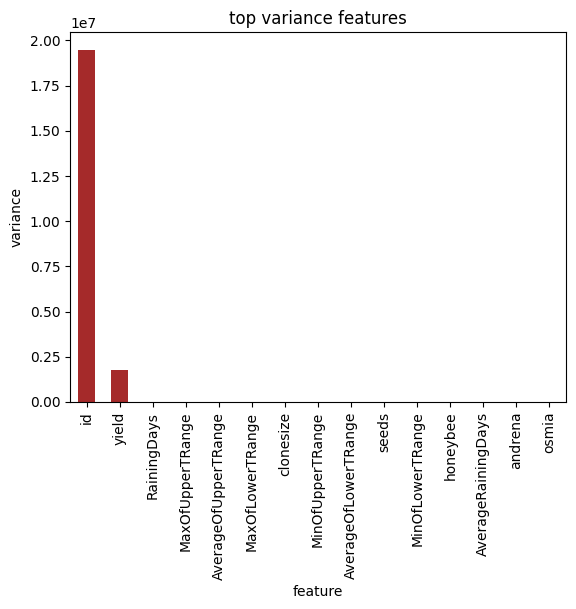

In [51]:
plt.figure()
train_df[num_cols].var().sort_values(ascending=False).head(15).plot(kind="bar", color="brown")
plt.title("top variance features")
plt.xlabel("feature")
plt.ylabel("variance")
plt.xticks(rotation=90)
plt.show()

## 🧠 Model Architecture & Training
A **HistGradientBoostingRegressor** is used as the predictive model.  
This algorithm is efficient for large datasets and captures non-linear relationships effectively.  
Model performance is evaluated using **5-fold cross validation** with **RMSE** as the evaluation metric.

In [52]:
x = train_df.drop(columns=[target_col], errors="ignore")

In [53]:
y = train_df[target_col].copy()

In [54]:
x_test = test_df.copy()

In [55]:
x = x.drop(columns=[id_col], errors="ignore")

In [56]:
x_test = x_test.drop(columns=[id_col], errors="ignore")

In [57]:
num_cols = x.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = x.columns.difference(num_cols).tolist()

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot", OneHotEncoder(handle_unknown="ignore"))])

pre = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)])

In [58]:
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=None,
    max_iter=2000,
    max_leaf_nodes=64,
    min_samples_leaf=20,
    random_state=42)

pipe = Pipeline([("pre", pre), ("model", model)])

In [59]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse = -cross_val_score(pipe, x, y, cv=cv, scoring="neg_root_mean_squared_error")

In [60]:
pipe.fit(x, y)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['clonesize', 'honeybee',
                                                   'bumbles', 'andrena',
                                                   'osmia', 'MaxOfUpperTRange',
                                                   'MinOfUpperTRange',
                                                   'AverageOfUpperTRange',
                                                   'MaxOfLowerTRange',
                                                   'MinOfLowerTRange',
                                                   'AverageOfLowerTRange',
                                                   'RainingDays',
                                                   'AverageRainingDays',
                                                   'fruitset', 'fruitmass',
                                                   'seeds']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('model',
                 HistGradientBoostingRegressor(learning_rate=0.05,
                                               max_iter=2000, max_leaf_nodes=64,
                                               random_state=42))])

In [61]:
pred = pipe.predict(x_test)

In [62]:
sub = sample_df.copy()
sub[target_col] = pred
sub.to_csv("submission.csv", index=False)

In [63]:
sub.head()

,id,yield
0,15289,4298.988835
1,15290,6151.719199
2,15291,7188.087751
3,15292,4669.513551
4,15293,4011.813726


In [64]:
import joblib

joblib.dump(pipe, "blueberry_model.pkl")

['blueberry_model.pkl']

In [65]:
from sklearn.metrics import mean_squared_error

In [66]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_cv = -cross_val_score(pipe, x, y, cv=cv, scoring="neg_root_mean_squared_error")
rmse_cv.mean(), rmse_cv.std()

(np.float64(567.2713263960547), np.float64(16.41608203153981))

In [67]:
pipe.fit(x, y)
train_pred = pipe.predict(x)

mse_train = mean_squared_error(y, train_pred)
rmse_train = np.sqrt(mse_train)

rmse_train

np.float64(510.62247614390833)

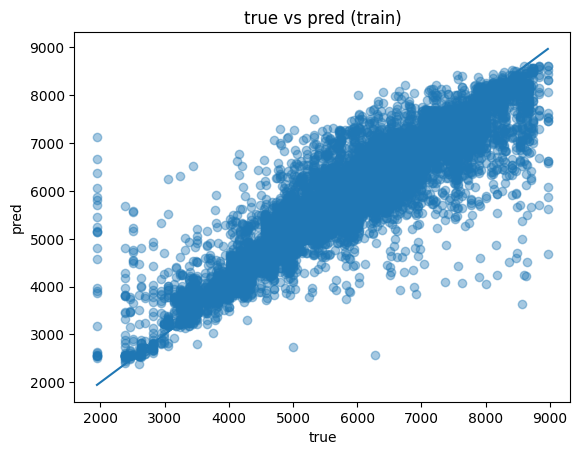

In [68]:
plt.figure()
plt.scatter(y, train_pred, alpha=0.4)
plt.xlabel("true")
plt.ylabel("pred")
plt.title("true vs pred (train)")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()